<a href="https://colab.research.google.com/github/Maxxx-VS/IMA_SibADI/blob/main/ML_2_6_%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Задание 2.6. Классификация изображений (нейронная сеть прямого распространения)

In [1]:
!unzip -qo /content/images.zip -d /content/
!ls /content/train /content/val /content/test | head

/content/test:
cat
fish

/content/train:
cat
fish

/content/val:
cat


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True


def check_image(path):
    try:
        im = Image.open(path)
        return True
    except:
        return False

In [3]:
img_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data = torchvision.datasets.ImageFolder(
    root='/content/train/', transform=img_transforms, is_valid_file=check_image)
val_data = torchvision.datasets.ImageFolder(
    root='/content/val/', transform=img_transforms, is_valid_file=check_image)
test_data = torchvision.datasets.ImageFolder(
    root='/content/test/', transform=img_transforms, is_valid_file=check_image)

batch_size = 64
train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size)
val_data_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size)
test_data_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size)

print('Классы:', train_data.classes)
print('train:', len(train_data), 'val:', len(val_data), 'test:', len(test_data))

Классы: ['cat', 'fish']
train: 659 val: 107 test: 163


In [4]:
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(12288, 84)
        self.fc2 = nn.Linear(84, 50)
        self.fc3 = nn.Linear(50, 2)

    def forward(self, x):
        x = x.view(-1, 12288)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


simplenet = SimpleNet()

In [5]:
optimizer = optim.Adam(simplenet.parameters(), lr=0.001)

In [6]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('device:', device)
simplenet.to(device)

device: cuda


SimpleNet(
  (fc1): Linear(in_features=12288, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=2, bias=True)
)

In [7]:
def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device='cpu'):
    for epoch in range(1, epochs + 1):
        training_loss = 0.0
        valid_loss = 0.0
        model.train()

        for batch in train_loader:
            optimizer.zero_grad()
            inputs, targets = batch
            inputs = inputs.to(device)
            targets = targets.to(device)
            output = model(inputs)
            loss = loss_fn(output, targets)
            loss.backward()
            optimizer.step()
            training_loss += loss.data.item() * inputs.size(0)

        training_loss /= len(train_loader.dataset)

        model.eval()
        num_correct = 0
        num_examples = 0
        for batch in val_loader:
            inputs, targets = batch
            inputs = inputs.to(device)
            targets = targets.to(device)
            output = model(inputs)
            loss = loss_fn(output, targets)
            valid_loss += loss.data.item() * inputs.size(0)
            correct = torch.eq(torch.max(F.softmax(output, dim=1), dim=1)[1], targets)
            num_correct += torch.sum(correct).item()
            num_examples += correct.shape[0]

        valid_loss /= len(val_loader.dataset)

        print('Epoch: {}, Training Loss: {:.2f}, Validation Loss: {:.2f}, accuracy = {:.2f}'.format(
            epoch, training_loss, valid_loss, num_correct / num_examples))

In [8]:
train(simplenet, optimizer, torch.nn.CrossEntropyLoss(),
      train_data_loader, val_data_loader, epochs=5, device=device)

Epoch: 1, Training Loss: 3.00, Validation Loss: 2.42, accuracy = 0.36
Epoch: 2, Training Loss: 1.40, Validation Loss: 1.53, accuracy = 0.59
Epoch: 3, Training Loss: 0.81, Validation Loss: 0.84, accuracy = 0.55
Epoch: 4, Training Loss: 0.52, Validation Loss: 0.83, accuracy = 0.68
Epoch: 5, Training Loss: 0.39, Validation Loss: 0.82, accuracy = 0.62


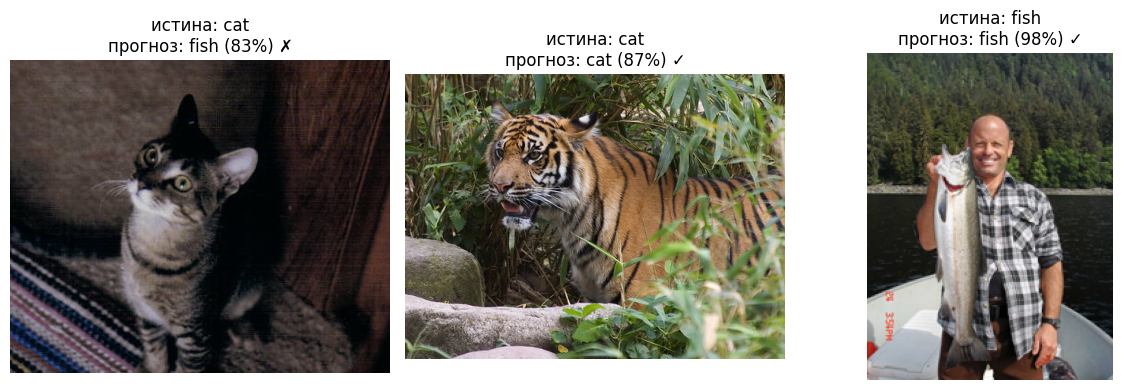

In [11]:
import random
import matplotlib.pyplot as plt

labels = ['cat', 'fish']

indices = random.sample(range(len(val_data)), 3)

simplenet.eval()
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, idx in zip(axes, indices):
    path, true_idx = val_data.samples[idx]
    img_pil = Image.open(path).convert('RGB')

    tensor = img_transforms(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(simplenet(tensor), dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    true_label = labels[true_idx]
    pred_label = labels[pred_idx]
    ok = '✓' if pred_idx == true_idx else '✗'

    ax.imshow(img_pil)
    ax.set_title(f'истина: {true_label}\nпрогноз: {pred_label} ({confidence:.0%}) {ok}')
    ax.axis('off')

plt.tight_layout()
plt.show()